In [211]:
import os.path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

In [212]:
patient = pd.read_csv(os.path.join("data", "working_data", "week_5_data.csv")) 
air_pollution = pd.read_csv(os.path.join("data", "week_6", "cri_air_pollution.csv"))

In [213]:
patient.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,CURRENT_AGE,TOTAL_CONDITIONS,TOTAL_ENCOUNTER,ASTHMA_REASON_ENCOUNTER,SYMPTOM_ENCOUNTER,EMERGENCY_ENCOUNTER,URGENT_CARE_ENCOUNTER,ASTHMA_FU_ENCOUNTER,ACTIVE_ALLERGY_COUNT,ACTIVE_MEDICATION_COUNT,ACTIVE_CAREPLAN_COUNT
0,d54a7e5d-02cc-3df8-fa87-a7133bb8dbd0,2019-05-02,NaN,999-87-5214,NaN,NaN,NaN,Ferdinand55,Mitchell808,NaN,NaN,NaN,white,nonhispanic,M,Oxford Massachusetts US,620 Luettgen Avenue,Easthampton,Massachusetts,Hampshire County,25015.0,1027,42.260142,-72.798090,11931.12,0.00,168858,7.0,1,22,6,3,NaN,NaN,3.0,7.0,2,2
1,a8f47b70-4707-d5e3-b3e3-b40c74cfc220,2016-04-05,NaN,999-86-6187,NaN,NaN,NaN,Ariel183,Emmerich580,NaN,NaN,NaN,white,nonhispanic,M,Southborough Massachusetts US,149 Weimann Viaduct Apt 9,Framingham,Massachusetts,Middlesex County,25017.0,1702,42.290083,-71.459564,3255.03,18441.83,12983,10.0,6,33,4,5,2.0,3.0,3.0,8.0,2,3
2,1ebb8037-f48c-5aae-61b8-bca2b28fd86e,2018-04-16,NaN,999-56-5258,NaN,NaN,NaN,Lisa683,Durgan499,NaN,NaN,NaN,white,nonhispanic,F,Quincy Massachusetts US,533 Wuckert Junction Suite 37,Wilmington,Massachusetts,Middlesex County,25017.0,1887,42.573334,-71.150584,8051.91,8174.95,141803,8.0,3,31,1,5,1.0,2.0,NaN,8.0,2,3
3,9ad79ef6-a38d-eec0-14ef-ab987cd94308,2018-01-12,NaN,999-71-4164,NaN,NaN,NaN,Lana840,Maggio310,NaN,NaN,NaN,white,nonhispanic,F,Southbridge Massachusetts US,130 Rodriguez Overpass Apt 96,Lowell,Massachusetts,Middlesex County,25017.0,1850,42.617935,-71.305313,11337.43,316.41,42817,8.0,2,19,1,4,NaN,NaN,NaN,NaN,2,1
4,e6012a16-d3a8-4cbd-a4a2-f94ae5c48685,2016-05-07,NaN,999-53-5147,NaN,NaN,NaN,Chu728,Corwin846,NaN,NaN,NaN,white,nonhispanic,F,Belmont Massachusetts US,559 Greenfelder Manor Apt 45,Holyoke,Massachusetts,Hampden County,25013.0,1040,42.165733,-72.657553,3185.21,28674.85,24016,10.0,7,34,4,5,3.0,2.0,3.0,10.0,2,3


In [214]:
# 1.1	Import the air quality dataset and familiarize yourself with this dataset. Print the number of counties for which the data is available.

print(f"Counties available: {air_pollution['County'].nunique()}")

Counties available: 351


In [215]:
# 1.2	Transform the longitudinal air quality dataset into a format that can be merged with cross-sectional tables. 
# Merge it with your data from last week’s exercise (see task 3.1).


air_pollution_wide = air_pollution.pivot(
    index="County",
    columns="Year",
    values="Measurement_avg pm25").reset_index().rename(columns={"County": "COUNTY"})

# Flatten column names: int years → labelled strings
air_pollution_wide.columns = (
    ["COUNTY"] + [f"pm25_{int(y)}" for y in air_pollution_wide.columns[1:]]
)

In [216]:
air_pollution_wide.head()

,COUNTY,pm25_2017,pm25_2018,pm25_2019,pm25_2020,pm25_2021,pm25_2022,pm25_2023,pm25_2024
0,Abington,10.730195,9.430195,8.730195,8.230195,8.730195,7.930195,7.730195,6.530195
1,Acton,11.000000,10.000000,9.000000,8.500000,9.100000,8.600000,8.400000,7.800000
2,Acushnet,8.431250,7.831250,6.931250,6.531250,7.131250,6.231250,6.231250,5.331250
3,Adams,10.021875,9.821875,8.921875,8.421875,8.821875,8.321875,8.321875,8.621875
4,Agawam,11.367045,10.567045,9.267045,8.667045,10.067045,8.767045,8.767045,8.267045


In [217]:
patient = pd.merge(patient, air_pollution_wide, how="left", left_on="CITY",              
right_on="COUNTY")

# Drop the duplicate and rename the keeper
patient = patient.drop(columns=["COUNTY_x", "COUNTY_y"])

patient.head()   

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,CURRENT_AGE,TOTAL_CONDITIONS,TOTAL_ENCOUNTER,ASTHMA_REASON_ENCOUNTER,SYMPTOM_ENCOUNTER,EMERGENCY_ENCOUNTER,URGENT_CARE_ENCOUNTER,ASTHMA_FU_ENCOUNTER,ACTIVE_ALLERGY_COUNT,ACTIVE_MEDICATION_COUNT,ACTIVE_CAREPLAN_COUNT,pm25_2017,pm25_2018,pm25_2019,pm25_2020,pm25_2021,pm25_2022,pm25_2023,pm25_2024
0,d54a7e5d-02cc-3df8-fa87-a7133bb8dbd0,2019-05-02,NaN,999-87-5214,NaN,NaN,NaN,Ferdinand55,Mitchell808,NaN,NaN,NaN,white,nonhispanic,M,Oxford Massachusetts US,620 Luettgen Avenue,Easthampton,Massachusetts,25015.0,1027,42.260142,-72.798090,11931.12,0.00,168858,7.0,1,22,6,3,NaN,NaN,3.0,7.0,2,2,9.231250,8.431250,7.331250,6.831250,7.931250,7.031250,6.931250,6.531250
1,a8f47b70-4707-d5e3-b3e3-b40c74cfc220,2016-04-05,NaN,999-86-6187,NaN,NaN,NaN,Ariel183,Emmerich580,NaN,NaN,NaN,white,nonhispanic,M,Southborough Massachusetts US,149 Weimann Viaduct Apt 9,Framingham,Massachusetts,25017.0,1702,42.290083,-71.459564,3255.03,18441.83,12983,10.0,6,33,4,5,2.0,3.0,3.0,8.0,2,3,11.332123,10.332123,9.432123,8.832123,9.632123,8.932123,8.732123,7.832123
2,1ebb8037-f48c-5aae-61b8-bca2b28fd86e,2018-04-16,NaN,999-56-5258,NaN,NaN,NaN,Lisa683,Durgan499,NaN,NaN,NaN,white,nonhispanic,F,Quincy Massachusetts US,533 Wuckert Junction Suite 37,Wilmington,Massachusetts,25017.0,1887,42.573334,-71.150584,8051.91,8174.95,141803,8.0,3,31,1,5,1.0,2.0,NaN,8.0,2,3,10.514773,9.314773,8.414773,8.014773,8.714773,8.014773,7.614773,6.814773
3,9ad79ef6-a38d-eec0-14ef-ab987cd94308,2018-01-12,NaN,999-71-4164,NaN,NaN,NaN,Lana840,Maggio310,NaN,NaN,NaN,white,nonhispanic,F,Southbridge Massachusetts US,130 Rodriguez Overpass Apt 96,Lowell,Massachusetts,25017.0,1850,42.617935,-71.305313,11337.43,316.41,42817,8.0,2,19,1,4,NaN,NaN,NaN,NaN,2,1,10.687625,9.587625,8.587625,8.187625,8.887625,8.287625,7.987625,7.387625
4,e6012a16-d3a8-4cbd-a4a2-f94ae5c48685,2016-05-07,NaN,999-53-5147,NaN,NaN,NaN,Chu728,Corwin846,NaN,NaN,NaN,white,nonhispanic,F,Belmont Massachusetts US,559 Greenfelder Manor Apt 45,Holyoke,Massachusetts,25013.0,1040,42.165733,-72.657553,3185.21,28674.85,24016,10.0,7,34,4,5,3.0,2.0,3.0,10.0,2,3,11.128409,10.328409,9.128409,8.628409,9.928409,8.728409,8.728409,8.228409


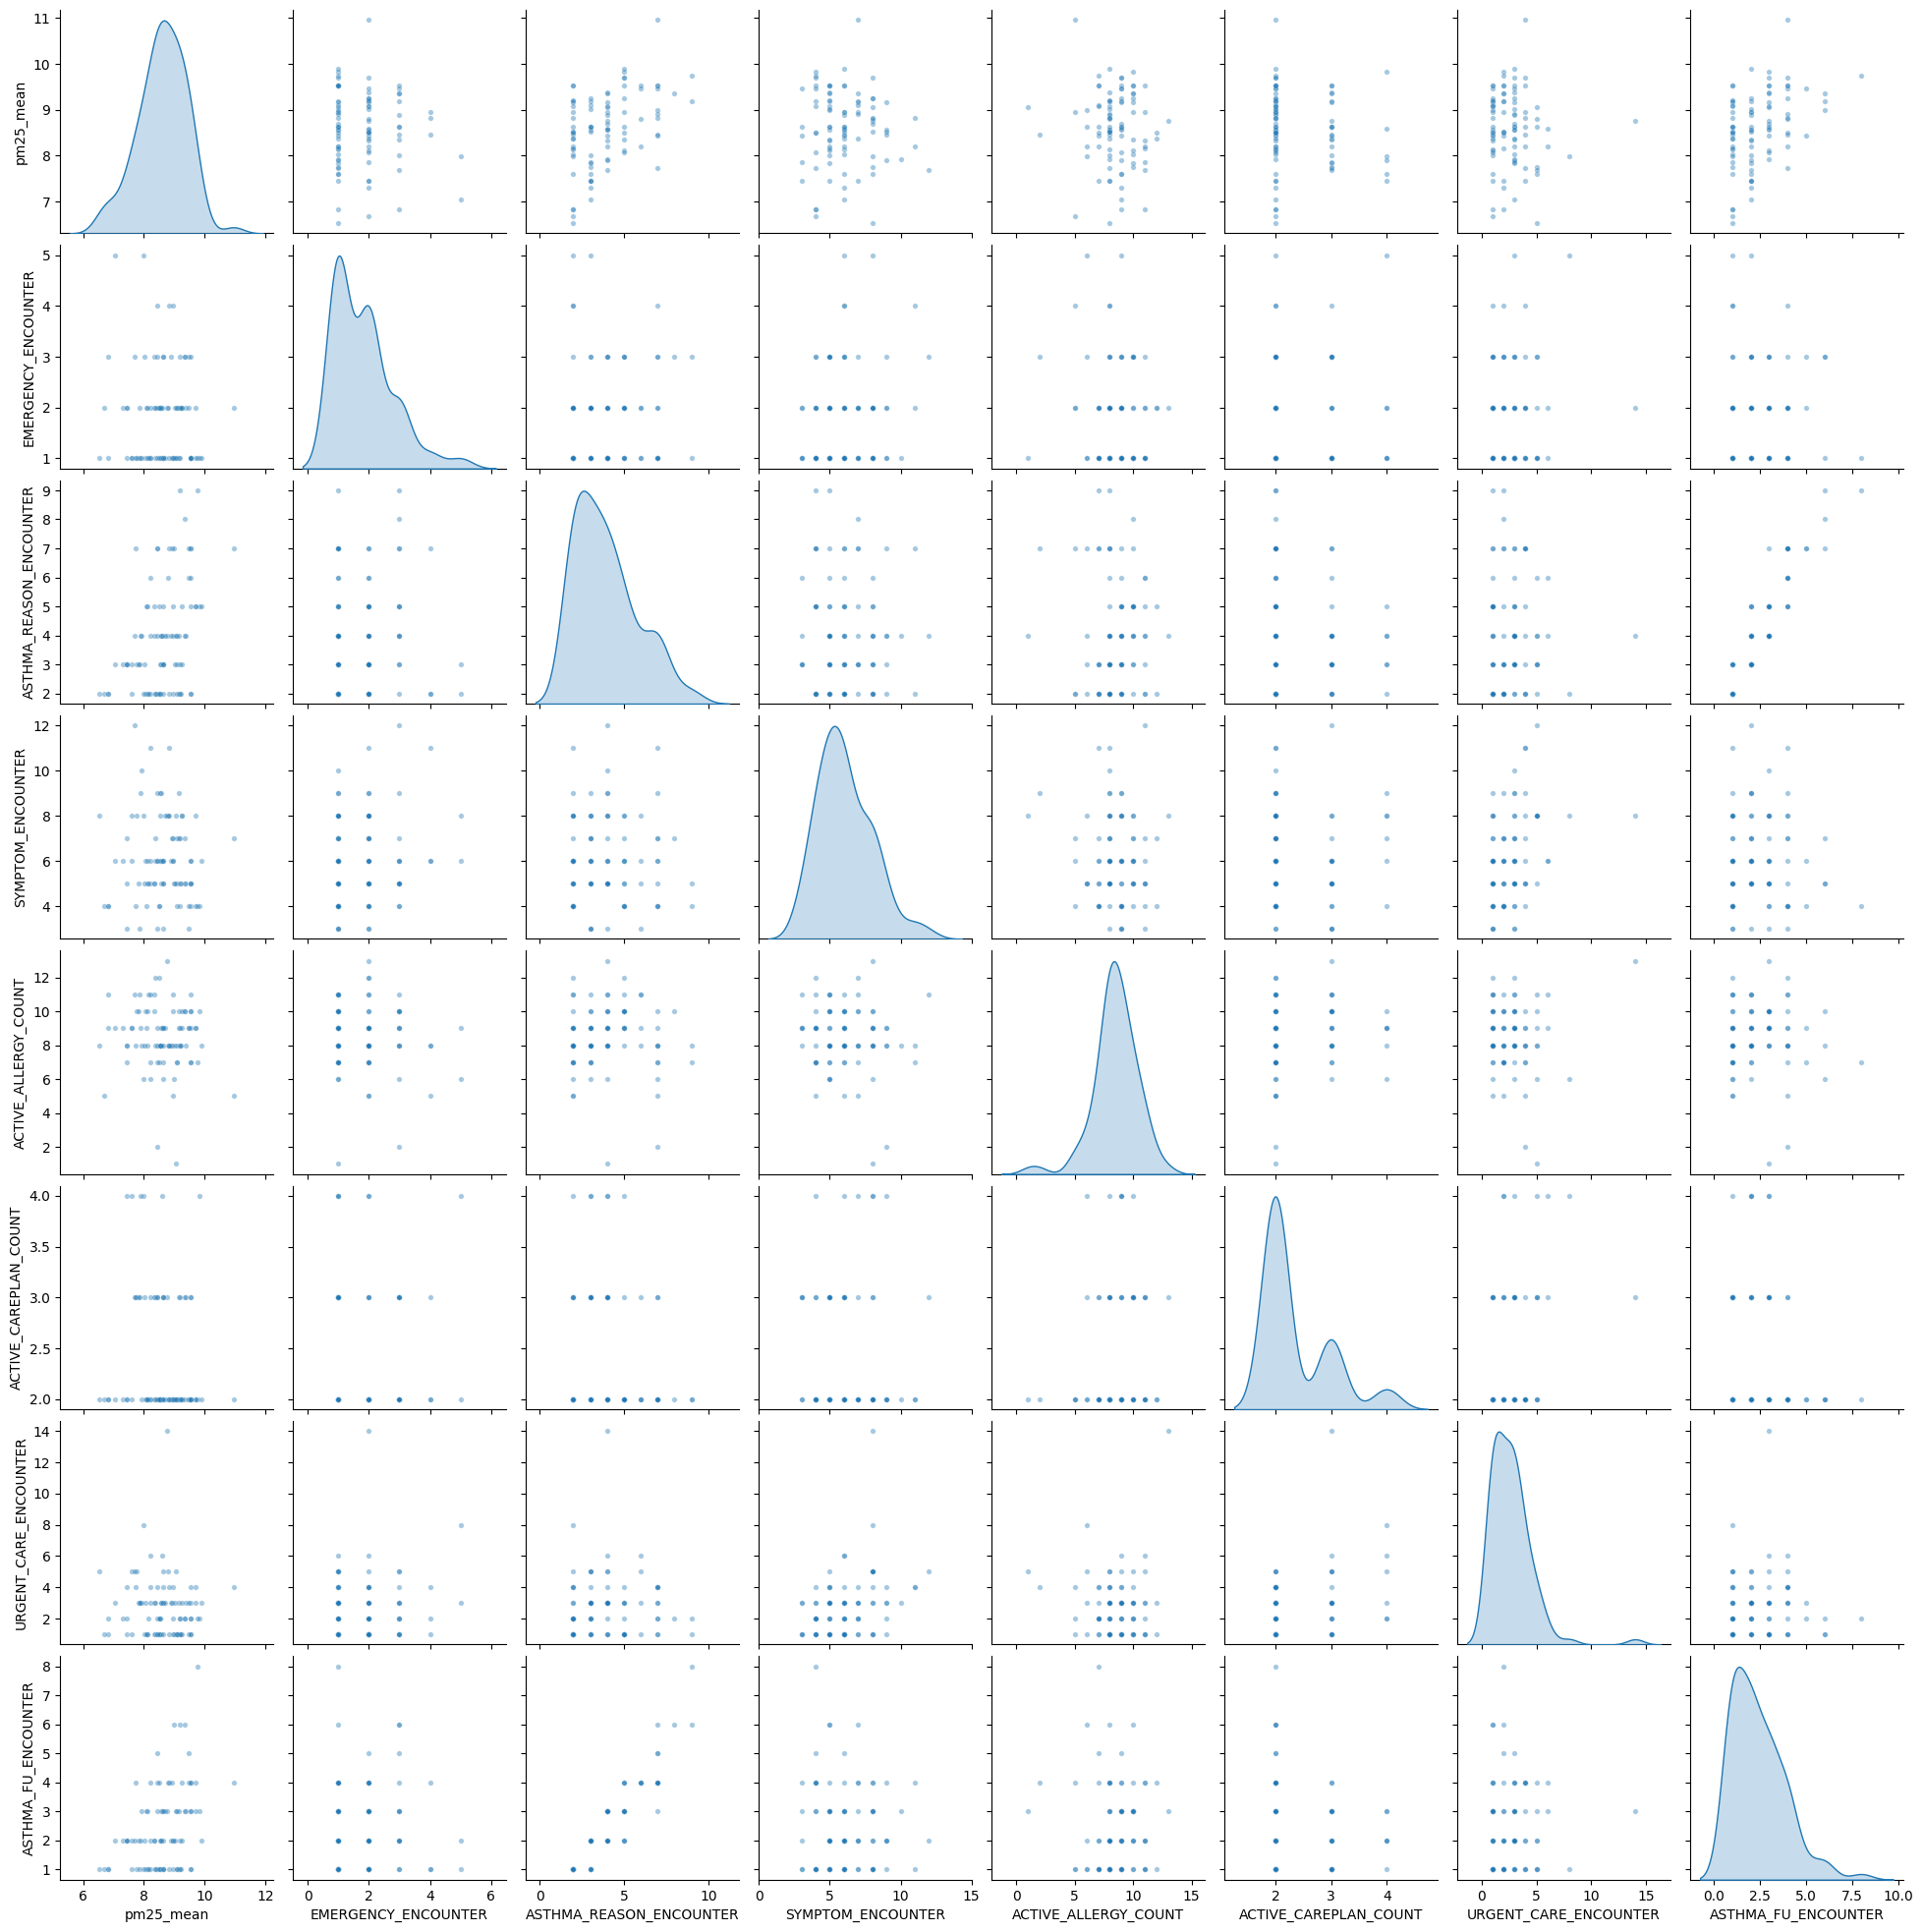

In [ ]:
# 2.1	Explore the air quality data by using descriptive statistics and data visualization. What relations do you see with your asthma severity measures?

# using pairplot for a general overview of relationships between air pollution and severity measures. We will do more specific analyses later, but this is a good starting point to get a sense of the data.
pm25_cols = [c for c in patient.columns if c.startswith("pm25_")]
patient["pm25_mean"] = patient[pm25_cols].mean(axis=1)

severity_cols = [
    "pm25_mean",
    "EMERGENCY_ENCOUNTER",
    "ASTHMA_REASON_ENCOUNTER",
    "SYMPTOM_ENCOUNTER",
    "ACTIVE_ALLERGY_COUNT",
    "ACTIVE_CAREPLAN_COUNT",
    "URGENT_CARE_ENCOUNTER",
    "ASTHMA_FU_ENCOUNTER"
]

sns.pairplot(
    patient[severity_cols].dropna(),
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15}
)

In [219]:
print("=== PM2.5 Stats ===")                                                             
display(patient[pm25_cols].describe())
print("\n=== Severity Stats ===")
display(patient[severity_cols].describe())

=== PM2.5 Stats ===


,pm25_2017,pm25_2018,pm25_2019,pm25_2020,pm25_2021,pm25_2022,pm25_2023,pm25_2024
count,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000
mean,10.453416,9.518933,8.616175,8.137899,8.853761,8.056175,7.870657,6.982726
std,1.074327,0.821224,0.835257,0.839733,0.876719,0.804864,0.742400,0.692781
min,6.350781,6.750781,6.150781,5.850781,5.950781,5.450781,5.350781,4.950781
25%,9.904464,9.027232,8.028237,7.528237,8.268580,7.623864,7.427232,6.567857
50%,10.650000,9.600000,8.701500,8.187625,8.905753,8.116051,7.927619,7.090501
75%,11.278054,10.111477,9.267045,8.795536,9.556250,8.678793,8.466484,7.400000
max,13.000000,11.800000,11.000000,10.500000,11.300000,10.600000,10.200000,9.300000



=== Severity Stats ===


,pm25_mean,EMERGENCY_ENCOUNTER,ASTHMA_REASON_ENCOUNTER,SYMPTOM_ENCOUNTER,ACTIVE_ALLERGY_COUNT,ACTIVE_CAREPLAN_COUNT,URGENT_CARE_ENCOUNTER,ASTHMA_FU_ENCOUNTER
count,290.000000,190.000000,300.000000,300.000000,231.000000,300.000000,187.000000,222.000000
mean,8.561218,1.705263,2.973333,4.943333,8.541126,2.070000,2.566845,2.243243
std,0.811426,1.153542,1.854026,2.031554,1.828945,0.735006,2.631401,1.316214
min,5.850781,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,8.080547,1.000000,1.000000,3.000000,8.000000,2.000000,1.000000,1.000000
50%,8.635227,1.000000,2.500000,5.000000,8.000000,2.000000,2.000000,2.000000
75%,9.159417,2.000000,4.000000,6.000000,10.000000,2.000000,3.000000,3.000000
max,10.962500,10.000000,9.000000,12.000000,15.000000,4.000000,31.000000,8.000000


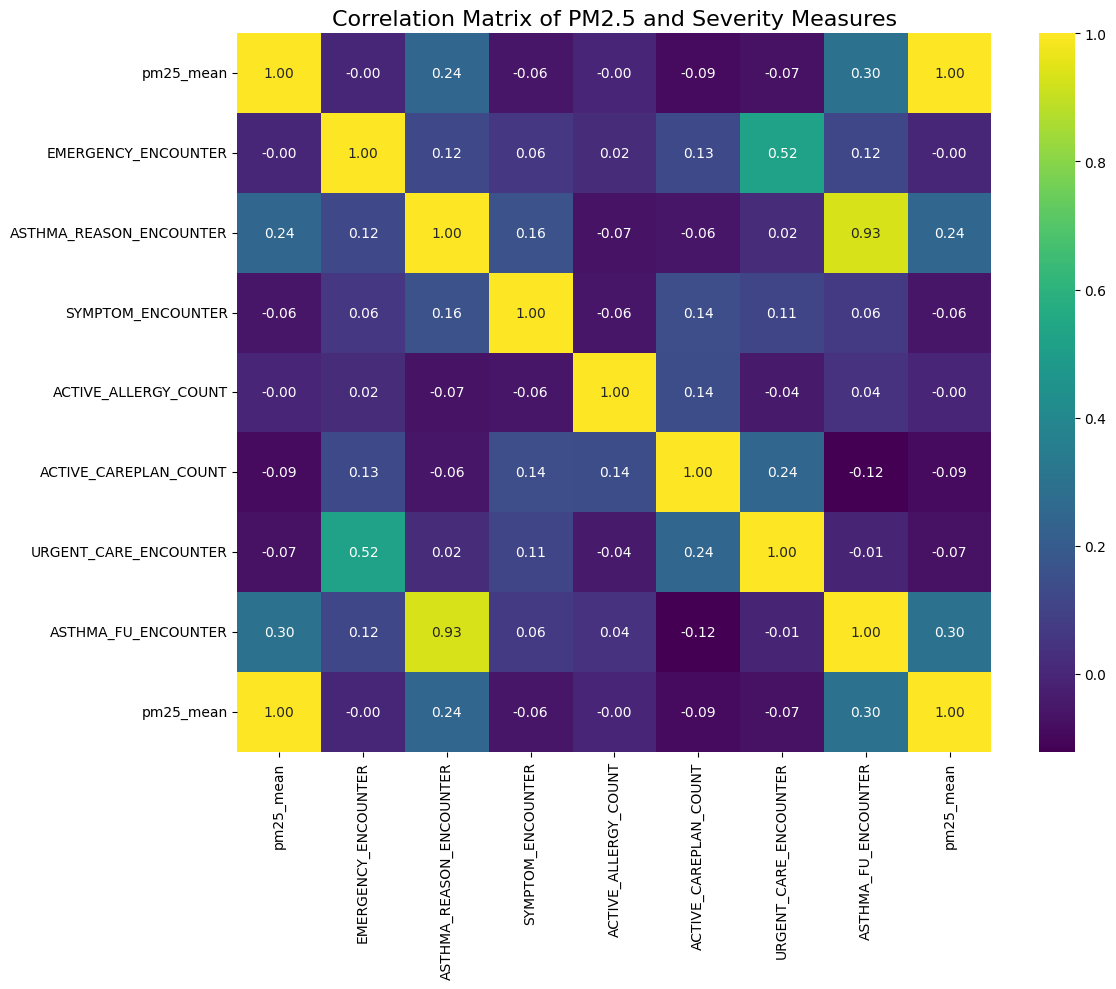

In [239]:
corr_cols = severity_cols + ["pm25_mean"]
corr = patient[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Correlation Matrix of PM2.5 and Severity Measures", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# 2.2	Create categories, that allows you to explore the relationship between air pollution and asthma severity.
# Note: Remember one of the earlier exercises where we discussed, how binary groups like urban vs. rural areas might be helpful to answer research questions.

# Binary split at the median
median_pm25 = patient["pm25_mean"].median()
patient["pm25_group"] = pd.cut(
    patient["pm25_mean"],
    bins=[-float("inf"), median_pm25, float("inf")],
    labels=["Low PM2.5", "High PM2.5"]
)

print(patient.groupby("pm25_group")[severity_cols].mean().round(2))

            pm25_mean  EMERGENCY_ENCOUNTER  ASTHMA_REASON_ENCOUNTER  SYMPTOM_ENCOUNTER  ACTIVE_ALLERGY_COUNT  ACTIVE_CAREPLAN_COUNT  URGENT_CARE_ENCOUNTER  ASTHMA_FU_ENCOUNTER
pm25_group                                                                                                                                                                     
Low PM2.5        7.93                 1.75                     2.66               5.06                  8.60                   2.19                   2.77                 1.92
High PM2.5       9.20                 1.68                     3.33               4.81                  8.46                   1.94                   2.34                 2.61

Quartile category distribution:
pm25_quartile
Q1    73
Q2    73
Q3    72
Q4    72


C:\Rtemp\ipykernel_30628\3548921998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Rtemp\ipykernel_30628\3548921998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Rtemp\ipykernel_30628\3548921998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Rtemp\ipykernel_30628\3548921998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Rtemp\ipykernel_30628\3548921998.py:9

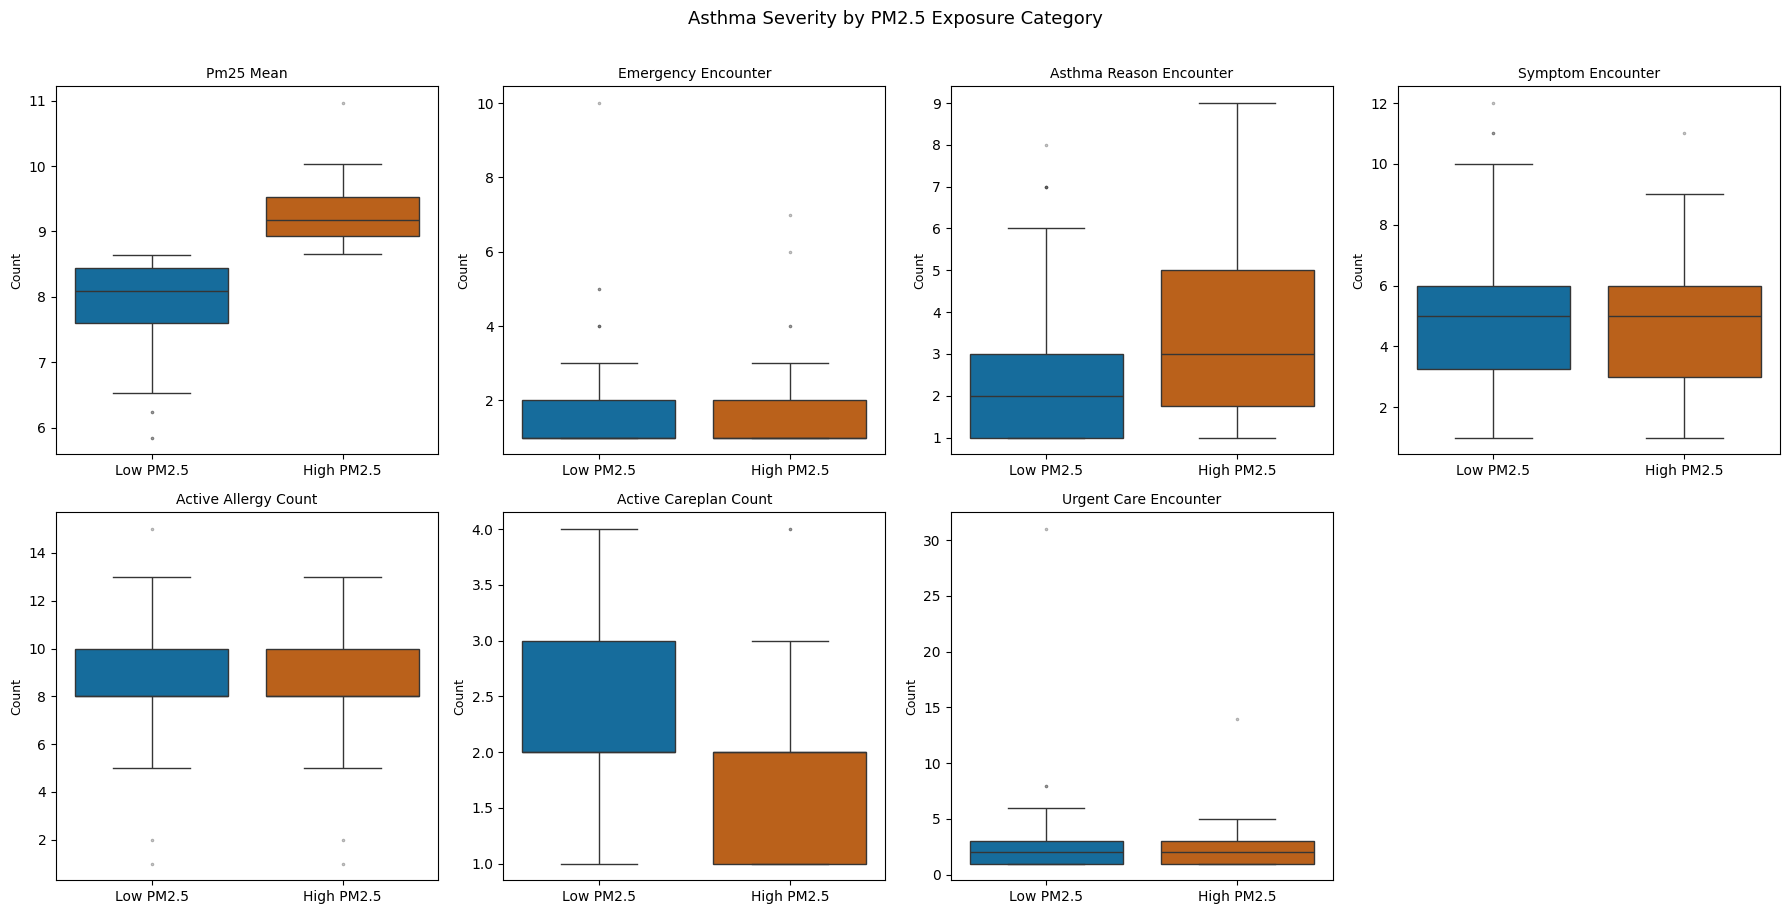

In [ ]:
# 2.3	Create at least two data visualizations for the exploration of disease severity vs. air pollution.

palette = {'High PM2.5': '#440154', 'Low PM2.5': '#26828e'}

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
axes = axes.flatten()

for ax, col in zip(axes, severity_cols):
    sns.boxplot(
        data=patient,
        x='pm25_group', y=col,
        order=['Low PM2.5', 'High PM2.5'],
        palette=palette,
        flierprops={"marker": ".", "markersize": 3, "alpha": 0.4},
        ax=ax
    )
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=9)

# hide the unused 8th subplot
axes[-1].set_visible(False)

fig.suptitle("Asthma Severity by PM2.5 Exposure Category", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

C:\Rtemp\ipykernel_30628\866707936.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Rtemp\ipykernel_30628\866707936.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Rtemp\ipykernel_30628\866707936.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Rtemp\ipykernel_30628\866707936.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Rtemp\ipykernel_30628\866707936.py:8: Fut

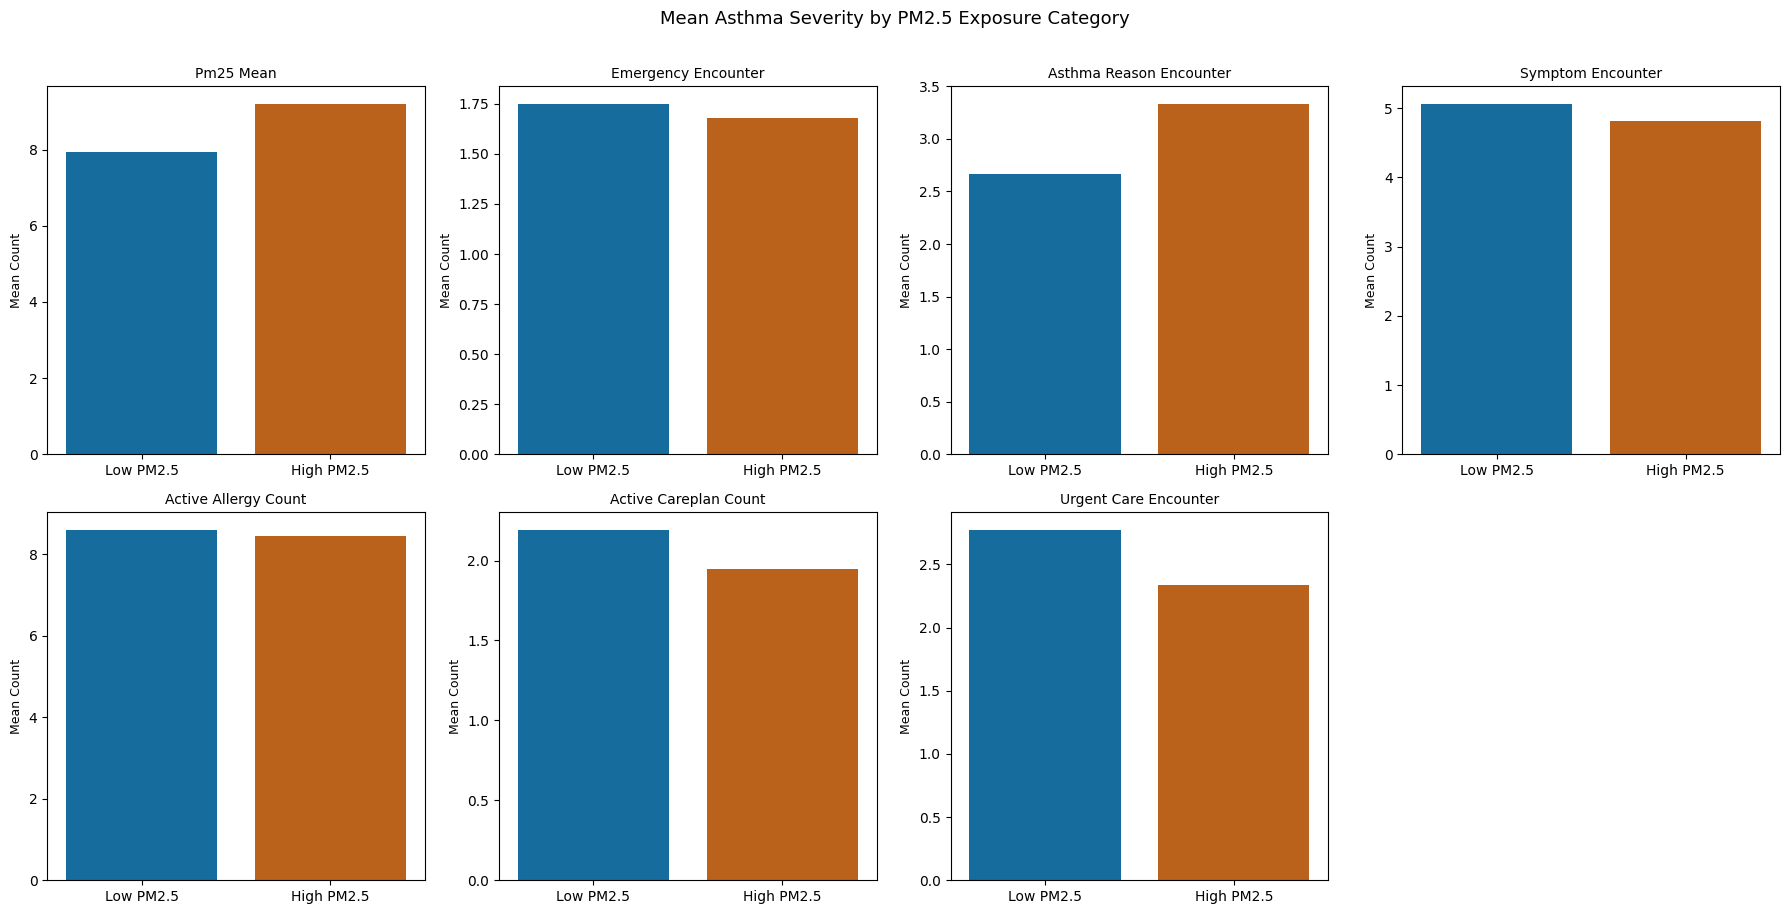

In [237]:
# bar chart: mean severity by PM2.5 group                                        
palette = {'High PM2.5': '#D55E00', 'Low PM2.5': '#0072B2'}

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
axes = axes.flatten()

for ax, col in zip(axes, severity_cols):                                          
    sns.barplot(                                                                  
        data=patient,                                                             
        x="pm25_group",                                                           
        y=col,                                                                    
        order=["Low PM2.5", "High PM2.5"],                                        
        palette=palette,
        errorbar=None,  # remove error bars for cleaner look                                                      
        ax=ax,                                                                    
    )                                                                             
    ax.set_title(col.replace("_", " ").title(), fontsize=10)                      
    ax.set_xlabel("")                                                             
    ax.set_ylabel("Mean Count", fontsize=9)                                       
                                                                            
axes[-1].set_visible(False)                                                       
                                                                            
fig.suptitle("Mean Asthma Severity by PM2.5 Exposure Category", fontsize=13, y=1.01)                                                                         
plt.tight_layout()                                                                
plt.show()

In [ ]:
# 3.1	Please export a single DataFrame that contains all variables you want to analyse further on. 
# This should include demographic data, clinical data and the air quality measures. Export this into a csv file.

patient.to_csv(os.path.join("data", "week_6", "week_6_data.csv"), index=False)
